In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, List, Any, Optional, Set, Tuple
import json

def _read_json(path: Path) -> Any:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def load_round_candidates(out_dir: Path, round_idx: int) -> List[Dict[str, Any]]:
    """读取某一轮的 candidates 列表；不存在则返回空列表。"""
    p = out_dir / f"R{round_idx}_candidates.json"
    if not p.exists():
        return []
    obj = _read_json(p)
    return obj.get("candidates", [])

def load_all_rounds(out_dir: Path) -> Dict[int, List[Dict[str, Any]]]:
    """扫描 out_dir 中所有 Rk_candidates.json，返回 {round_idx: [candidates...]}。"""
    out_dir = Path(out_dir)
    rounds: Dict[int, List[Dict[str, Any]]] = {}
    for p in out_dir.glob("R*_candidates.json"):
        # 文件名形如 R2_candidates.json
        stem = p.stem  # e.g. "R2_candidates"
        try:
            r_str = stem.split("_", 1)[0].lstrip("R")
            r = int(r_str)
        except Exception:
            continue
        rounds[r] = load_round_candidates(out_dir, r)
    return dict(sorted(rounds.items(), key=lambda kv: kv[0]))

def build_iteration_tree(out_dir: Path) -> Dict[str, Any]:
    """
    读取整个 out_dir 中所有 Rk_candidates.json，构建一个“迭代树”结构。

    返回结构示意：
    {
      "nodes": {
        "R1-01": {
          "round": 1,
          "audit_status": "PASS" | "FAIL" | "UNKNOWN",
          "hard_constraint_failures": [...],
          "is_good": True/False/None,
          "raw": {...原始 candidate 对象...},
        },
        ...
      },
      "parents": { "R2-01": ["R1-03", ...], ... },
      "children": { "R1-03": ["R2-01", ...], ... },
    }
    """
    out_dir = Path(out_dir)
    rounds = load_all_rounds(out_dir)

    nodes: Dict[str, Dict[str, Any]] = {}
    parents: Dict[str, List[str]] = {}
    children: Dict[str, List[str]] = {}

    for r, cand_list in rounds.items():
        for c in cand_list:
            cid = c.get("candidate_id")
            if not cid:
                continue

            audit_status = c.get("audit_status")
            hard_fail = c.get("hard_constraint_failures") or []

            if audit_status in ("PASS", "FAIL"):
                is_good: Optional[bool] = (audit_status == "PASS")
            else:
                # 没有审计信息时，设为 None
                is_good = None

            nodes[cid] = {
                "round": r,
                "audit_status": audit_status,
                "hard_constraint_failures": hard_fail,
                "is_good": is_good,
                "raw": c,
            }

    # 构建 parent/child 关系
    for cid, info in nodes.items():
        raw = info["raw"]
        # parent_candidates 是一个列表（仅在 result_driven / diagnosis_driven 且 round>1 时存在）
        parent_ids = raw.get("parent_candidates") or []
        # 过滤掉没有出现在 nodes 中的 parent
        parent_ids = [pid for pid in parent_ids if pid in nodes]

        if parent_ids:
            parents[cid] = parent_ids
            for pid in parent_ids:
                children.setdefault(pid, []).append(cid)

    return {
        "nodes": nodes,
        "parents": parents,
        "children": children,
    }

# ---------- 路径搜索相关 ----------

def find_paths_up_to_good(
    tree: Dict[str, Any],
    start_bad_id: str,
    max_depth: int = 10,
    allow_unknown_as_stop: bool = False,
) -> List[List[str]]:
    """
    从一个“坏节点”（通常 audit_status == FAIL）开始，沿着 parents 方向往上走，
    找到所有能走到“好节点”（audit_status == PASS）的路径。

    返回：若干条路径，每条路径是 [bad, ..., ancestor_good] 的 candidate_id 列表。
    """
    nodes = tree["nodes"]
    parents = tree["parents"]

    if start_bad_id not in nodes:
        return []

    results: List[List[str]] = []
    visited: Set[Tuple[str, int]] = set()

    def dfs(current_id: str, depth: int, path: List[str]):
        state = (current_id, depth)
        if state in visited:
            return
        visited.add(state)

        node = nodes.get(current_id, {})
        is_good = node.get("is_good")

        # 当前已经是“好节点”则把路径加入结果并停止向上
        if is_good is True:
            results.append(path[:])
            return

        # 不允许继续向上的终止条件
        if depth >= max_depth:
            return
        if allow_unknown_as_stop and is_good is None:
            return

        parent_ids = parents.get(current_id, [])
        if not parent_ids:
            return

        for pid in parent_ids:
            dfs(pid, depth + 1, path + [pid])

    dfs(start_bad_id, 0, [start_bad_id])
    return results


def find_any_path_bad_to_good(
    tree: Dict[str, Any],
    start_bad_id: str,
    max_depth: int = 10,
) -> Optional[List[str]]:
    """
    找到从坏节点到任意一个好祖先的“最短路径”（BFS），返回一条路径或 None。
    """
    nodes = tree["nodes"]
    parents = tree["parents"]
    if start_bad_id not in nodes:
        return None

    from collections import deque
    q = deque()
    q.append([start_bad_id])
    visited: Set[str] = {start_bad_id}

    while q:
        path = q.popleft()
        current = path[-1]
        node = nodes[current]
        if node.get("is_good") is True:
            return path

        if len(path) - 1 >= max_depth:
            continue

        for pid in parents.get(current, []):
            if pid not in visited:
                visited.add(pid)
                q.append(path + [pid])

    return None

# ---------- 可选：networkx 图 ----------

def to_networkx_digraph(tree: Dict[str, Any]):
    """
    若已安装 networkx，则把树结构转成 DiGraph（父 -> 子），便于后续做可视化。
    """
    try:
        import networkx as nx
    except ImportError:
        raise RuntimeError("networkx 未安装，请先 pip install networkx")

    G = nx.DiGraph()
    nodes = tree["nodes"]
    parents = tree["parents"]

    for cid, info in nodes.items():
        G.add_node(
            cid,
            round=info["round"],
            audit_status=info["audit_status"],
            is_good=info["is_good"],
        )

    for child, pids in parents.items():
        for pid in pids:
            if pid in nodes:
                # 边方向：parent -> child
                G.add_edge(pid, child)

    return G

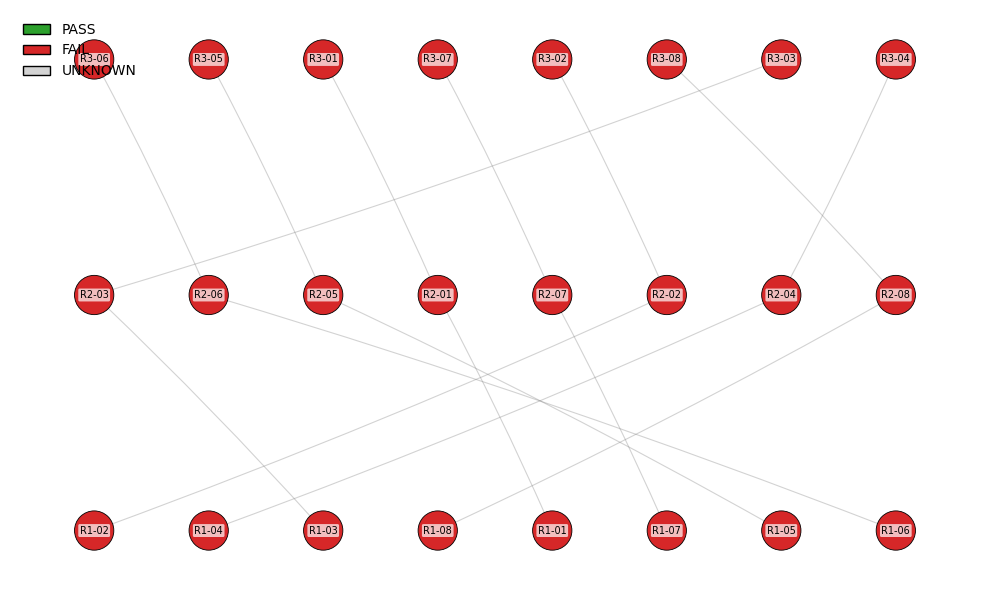

In [2]:
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt

# 1) 构建树 & 图
out_dir = Path("../src/sft_qwen3_14b_out")
tree = build_iteration_tree(out_dir)
G = to_networkx_digraph(tree)

# 2) multipartite_layout + 手动压缩坐标，减小“线的长度”
pos_raw = nx.multipartite_layout(G, subset_key="round", align="horizontal")
scale_x, scale_y = 0.4, 0.7   # x<1 把各轮之间拉近，y<1 把上下压扁一点
pos = {n: (x * scale_x, y * scale_y) for n, (x, y) in pos_raw.items()}

# 3) 节点颜色：PASS 绿色 / FAIL 红色 / 其它灰色
node_colors = []
for n in G.nodes():
    info = tree["nodes"][n]
    if info["audit_status"] == "PASS":
        node_colors.append("tab:green")
    elif info["audit_status"] == "FAIL":
        node_colors.append("tab:red")
    else:
        node_colors.append("lightgray")

plt.figure(figsize=(10, 6))   # 画布也稍微缩窄一点

# 4) 边：细、半透明、带箭头
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.35,
    edge_color="gray",
    arrows=True,
    arrowsize=10,
    width=0.8,
    connectionstyle="arc3,rad=0.02",  # 弧度变小，线看起来更直更短
)

# 5) 节点：放大圆圈
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=800,      # 原来 320，这里放大
    edgecolors="black",
    linewidths=0.6,
)

# 6) 标签
nx.draw_networkx_labels(
    G,
    pos,
    font_size=7,
    font_color="black",
    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="tab:green", edgecolor="black", label="PASS"),
    Patch(facecolor="tab:red", edgecolor="black", label="FAIL"),
    Patch(facecolor="lightgray", edgecolor="black", label="UNKNOWN"),
]
plt.legend(handles=legend_handles, loc="upper left", frameon=False)

plt.axis("off")
plt.tight_layout()
plt.show()